# Jacobi coordinates: N+1 harmonic oscillator in N-dimensional relative space

**Physics setup:**  
- $N+1$ identical 1D QHO particles with $m=1$, $\hbar=1$, frequency $\omega$.  
- Exact ground state energy: $E_\text{total} = (N+1)\,\omega/2$.  

**Jacobi trick:**  
- Sample in the $N$-dimensional Jacobi relative coordinate space $(u_1,\ldots,u_N)$ with CM fixed at 0.  
- The relative Hamiltonian has ground state $E_\text{rel} = N\,\omega/2$.  
- **User's job:** add $E_\text{CM} = \omega/2$ externally to recover $E_\text{total}$.  

**Key shapes:**
| Variable | Shape | Description |
|---|---|---|
| `shape` | `(n_chains, N)` | Sampler works in N Jacobi relative coords |
| Model input | `(n_chains, N+1)` | Model sees N+1 lab coords (reconstructed) |
| Model | `n_particles=N+1` | Physical particles, for correct permutation symmetry |

In [7]:
import jax
import jax.numpy as jnp
import optax
import numpy as np
import matplotlib.pyplot as plt

from qvarnet.train import train
from qvarnet.models.deep_set import DeepSet
from qvarnet.hamiltonian.continuous import HarmonicOscillatorHamiltonian

## System parameters

We simulate $N+1 = 11$ physical particles in their $N = 10$ relative Jacobi coordinates.

In [8]:
# ── Physical system ────────────────────────────────────────────────────────────
N_PARTICLES_PHYSICAL = 11   # N+1 — physical particles
N_JACOBI             = N_PARTICLES_PHYSICAL - 1  # N — Jacobi relative DoFs
DIM                  = 1
OMEGA                = 1.0

# Toggle: True  → sample in N Jacobi relative coords, model sees N+1 lab coords
#         False → sample directly in N+1 lab coords (baseline, no CM separation)
USE_JACOBI = False

# Exact energies
E_REL_EXACT   = N_JACOBI * OMEGA / 2               # VMC target when USE_JACOBI=True
E_CM_EXACT    = OMEGA / 2                          # add externally for total
E_TOTAL_EXACT = N_PARTICLES_PHYSICAL * OMEGA / 2   # ground state either way

print(f"N+1 physical particles : {N_PARTICLES_PHYSICAL}")
print(f"N Jacobi relative DoFs : {N_JACOBI}")
print(f"USE_JACOBI             : {USE_JACOBI}")
print(f"E_rel  (VMC target, Jacobi) : {E_REL_EXACT:.4f}")
print(f"E_CM   (add externally)     : {E_CM_EXACT:.4f}")
print(f"E_total                     : {E_TOTAL_EXACT:.4f}")

N+1 physical particles : 11
N Jacobi relative DoFs : 10
USE_JACOBI             : False
E_rel  (VMC target, Jacobi) : 5.0000
E_CM   (add externally)     : 0.5000
E_total                     : 5.5000


## Model

DeepSet with `n_particles = N+1` — it will receive N+1 lab coordinates reconstructed from N Jacobi coords.
Permutation symmetry is over the N+1 lab particles, which is the physical symmetry.

In [9]:
# ── Model ──────────────────────────────────────────────────────────────────────
model = DeepSet(
    n_particles=N_PARTICLES_PHYSICAL,   # N+1: model sees N+1 lab coords
    phi_hidden_architecture=[5],
    F_hidden_architecture=[5],
    hidden_internal_dimension=5,
    kernel_init=jax.nn.initializers.normal(stddev=0.01),
    bias_init=jax.nn.initializers.normal(stddev=0.01),
)
IS_LOG_MODEL = True

## Hamiltonian

With `use_jacobi=True`, `potential_energy` reconstructs lab coordinates from Jacobi coords before evaluating $V$.

In [10]:
# ── Hamiltonian ────────────────────────────────────────────────────────────────
# USE_JACOBI=True:  potential reconstructs X=C^T(u,0) before evaluating V(X)
# USE_JACOBI=False: potential evaluates V(x) directly on lab coords
if USE_JACOBI:
    hamiltonian = HarmonicOscillatorHamiltonian(
        omega=OMEGA,
        use_jacobi=True,
        n_particles=N_PARTICLES_PHYSICAL,
    )
else:
    hamiltonian = HarmonicOscillatorHamiltonian(omega=OMEGA)

## Optimizer and sampler

In [11]:
# ── Optimizer ──────────────────────────────────────────────────────────────────
optimizer = optax.adam(learning_rate=0.01)

# ── Sampler ────────────────────────────────────────────────────────────────────
# USE_JACOBI=True:  sampler in N-dim Jacobi space  → shape (n_chains, N)
# USE_JACOBI=False: sampler in N+1-dim lab space   → shape (n_chains, N+1)
N_CHAINS     = 2000
CHAIN_LENGTH = 100

DoF   = N_JACOBI if USE_JACOBI else N_PARTICLES_PHYSICAL
SHAPE = (N_CHAINS, DoF)

# chain_length MUST be > thermalization_steps — otherwise batch is empty → NaN
sampler_params = {
    "step_size":            0.5,
    "chain_length":         CHAIN_LENGTH + 1,
    "thermalization_steps": CHAIN_LENGTH,
    "thinning_factor":      1,
    "PBC":                  40.0,
}

print(f"SHAPE : {SHAPE}   (sampler DoF = {DoF})")

SHAPE : (2000, 11)   (sampler DoF = 11)


## Training

Pass `use_jacobi=True` and `n_dim_jacobi=1`.  
`train()` internally:
1. Initialises model parameters with shape `(n_chains, N+1)` (lab coords).
2. Wraps `model.apply` so that any `x ∈ R^N` is reconstructed to `x_lab ∈ R^{N+1}` before the model.
3. Kinetic energy is differentiated w.r.t. the N Jacobi inputs — by C orthogonality this equals the N-particle relative Laplacian.

In [12]:
history, cm_mean, cm_std = train(
    n_epochs=3_000,
    shape=SHAPE,
    model=model,
    optimizer=optimizer,
    sampler_params=sampler_params,
    hamiltonian=hamiltonian,
    rng_seed=42,
    warm_walkers=True,
    is_update_step_size=True,
    is_log_model=IS_LOG_MODEL,
    min_step=1e-5,
    max_step=5.0,
    save_checkpoints=False,
    checkpoint_path="./",
    use_jacobi=USE_JACOBI,
    n_dim_jacobi=1,
)

100%|██████████| 3000/3000 [00:38<00:00, 77.55it/s, E=5.50, sigma_E=0.02]


## Results

In [13]:
# ── Extract history ────────────────────────────────────────────────────────────
energies   = np.array([float(s.energy) for s in history])
stds       = np.array([float(s.std)    for s in history])
acc_rates  = np.array([float(jnp.mean(s.acceptance_rate)) for s in history])
step_sizes = np.array([float(s.step_size) for s in history])
steps      = np.arange(len(history))

# ── Summary ────────────────────────────────────────────────────────────────────
TAIL = 200
final_E_rel   = energies[-TAIL:].mean()
final_std_rel = stds[-TAIL:].mean()
E_total_reconstructed = final_E_rel + E_CM_EXACT

print(f"E_rel exact              : {E_REL_EXACT:.6f}")
print(f"E_rel VMC (last {TAIL})  : {final_E_rel:.6f} ± {final_std_rel:.6f}")
print(f"|E_rel - E_rel_exact|    : {abs(final_E_rel - E_REL_EXACT):.6f}")
print()
print(f"E_total = E_rel + E_CM   : {E_total_reconstructed:.6f}")
print(f"E_total exact            : {E_TOTAL_EXACT:.6f}")
print(f"Relative error           : {abs(E_total_reconstructed - E_TOTAL_EXACT) / E_TOTAL_EXACT * 100:.3f}%")

E_rel exact              : 5.000000
E_rel VMC (last 200)  : 5.500174 ± 0.023950
|E_rel - E_rel_exact|    : 0.500174

E_total = E_rel + E_CM   : 6.000174
E_total exact            : 5.500000
Relative error           : 9.094%


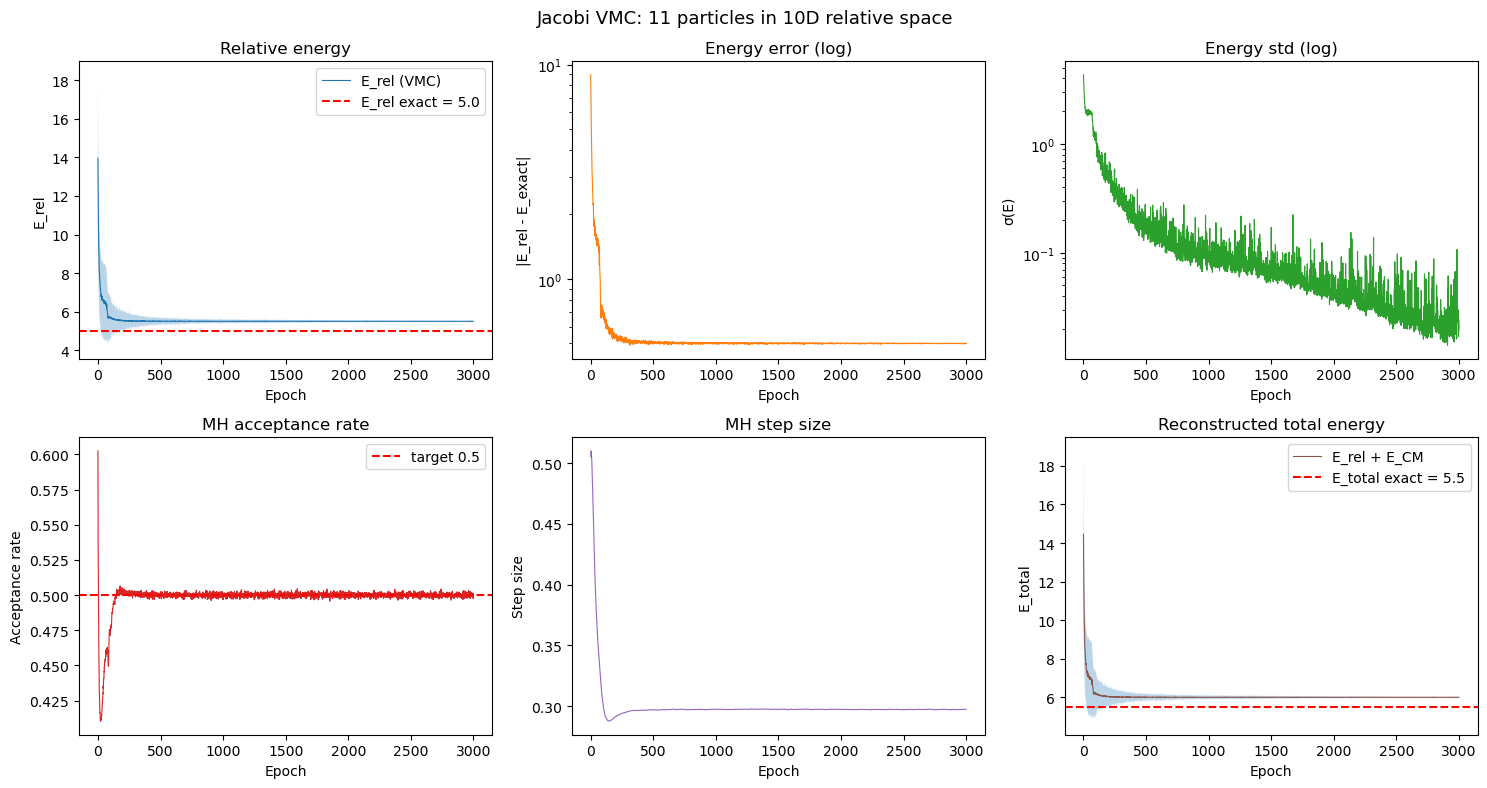

In [14]:
# ── Plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"Jacobi VMC: {N_PARTICLES_PHYSICAL} particles in {N_JACOBI}D relative space", fontsize=13)

ax = axes[0, 0]
ax.plot(steps, energies, lw=0.8, label='E_rel (VMC)')
ax.fill_between(steps, energies - stds, energies + stds, alpha=0.3)
ax.axhline(E_REL_EXACT, color='red', ls='--', label=f'E_rel exact = {E_REL_EXACT}')
ax.set_xlabel('Epoch'); ax.set_ylabel('E_rel'); ax.set_title('Relative energy'); ax.legend()

ax = axes[0, 1]
ax.semilogy(steps, np.abs(energies - E_REL_EXACT), lw=0.8, color='C1')
ax.set_xlabel('Epoch'); ax.set_ylabel('|E_rel - E_exact|'); ax.set_title('Energy error (log)')

ax = axes[0, 2]
ax.semilogy(steps, stds, lw=0.8, color='C2')
ax.set_xlabel('Epoch'); ax.set_ylabel('σ(E)'); ax.set_title('Energy std (log)')

ax = axes[1, 0]
ax.plot(steps, acc_rates, lw=0.8, color='C3')
ax.axhline(0.5, color='red', ls='--', label='target 0.5')
ax.set_xlabel('Epoch'); ax.set_ylabel('Acceptance rate'); ax.set_title('MH acceptance rate'); ax.legend()

ax = axes[1, 1]
ax.plot(steps, step_sizes, lw=0.8, color='C4')
ax.set_xlabel('Epoch'); ax.set_ylabel('Step size'); ax.set_title('MH step size')

# Energy reconstruction
ax = axes[1, 2]
E_total_trace = energies + E_CM_EXACT
ax.plot(steps, E_total_trace, lw=0.8, color='C5', label='E_rel + E_CM')
ax.fill_between(steps, E_total_trace - stds, E_total_trace + stds, alpha=0.3)
ax.axhline(E_TOTAL_EXACT, color='red', ls='--', label=f'E_total exact = {E_TOTAL_EXACT}')
ax.set_xlabel('Epoch'); ax.set_ylabel('E_total'); ax.set_title('Reconstructed total energy'); ax.legend()

plt.tight_layout()
plt.savefig('jacobi_ho_training.png', dpi=150, bbox_inches='tight')
plt.show()

## Sanity checks

Quick verification of the Jacobi utilities.

In [15]:
from qvarnet.utils.jacobi import jacobi_transformation, from_lab_to_jacobi, from_jacobi_to_lab

n = N_PARTICLES_PHYSICAL
C = jacobi_transformation(n)

print("C orthogonality (CC^T = I):")
print(jnp.allclose(C @ C.T, jnp.eye(n), atol=1e-6))

# Round-trip in Jacobi space
x_test = jnp.arange(n, dtype=float)
u = from_lab_to_jacobi(x_test[None], n, 1)[0]   # (n,)
x_back = from_jacobi_to_lab(u[None], n, 1)[0]    # (n,)
print(f"\nRound-trip error: {jnp.max(jnp.abs(x_test - x_back)):.2e}")

# CM coordinate is row N-1 of C
x_uniform = jnp.ones(n)
u_uniform = from_lab_to_jacobi(x_uniform[None], n, 1)[0]
print(f"\nUniform x → Jacobi: all relative coords zero? {jnp.allclose(u_uniform[:-1], 0, atol=1e-6)}")
print(f"CM coord u_{{N+1}} = {u_uniform[-1]:.4f} (should be sqrt({n}) = {jnp.sqrt(n):.4f})")

C orthogonality (CC^T = I):
True

Round-trip error: 4.77e-07

Uniform x → Jacobi: all relative coords zero? True
CM coord u_{N+1} = 3.3166 (should be sqrt(11) = 3.3166)
